In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
trainTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

testTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

trainDir = "D:/SeniorProject/LLMImageLabels"
testDir = "D:/SeniorProject/CroppedImages"

trainDataset = ImageFolder(root=trainDir, transform=trainTransform)
testDataset = ImageFolder(root=testDir, transform=testTransform)
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

In [6]:
def evaluateModel(model, testLoader):
  
  model.eval()
  correct = 0
  total = 0
  # Testing predictions on test set generated earlier and returning the accuracy
  with torch.no_grad():
    for images, labels in testLoader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

In [7]:
def trainModel(model, numEpochs):

    trainLosses = []
    trainAccuracies = []
    validLosses = []
    validAccuracies = []

    for epoch in range(numEpochs): 
        model.train()
        running_loss = 0.0
        correct = total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        trainLosses.append(running_loss / len(trainLoader))
        trainAccuracies.append(correct / total)

        model.eval()

        valLoss = 0
        correct = total = 0
        with torch.no_grad():
            for data in testLoader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        
        validLosses.append(valLoss / len(testLoader))
        validAccuracies.append(correct / total)
        print(f"Epoch {epoch + 1}/{numEpochs}, Train Loss: {trainLosses[-1]:.4f}, Train Accuracy: {trainAccuracies[-1]:.4f}, Validation Loss: {validLosses[-1]:.4f}, Validation Accuracy: {validAccuracies[-1]:.4f}")

        # If the validation accuracy improves, save the model
        if epoch == 0 or validAccuracies[-1] > max(validAccuracies[:-1]):
            torch.save(model.state_dict(), "best_modelReLU.pt")
            print("Model saved!")

    plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
    plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
    plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green") # This is not working
    plt.xlabel("Epoch")
    plt.ylabel("Loss/Accuracy")
    plt.title("Statistics vs. Epochs")
    plt.legend()
    plt.show()
    
    return model

In [8]:
def plotConfusionMatrix(model, testLoader):
    modelPrediction = []
    realLabels = []
    classNames = trainDataset.classes

    with torch.no_grad():
        for inputs, labels in testLoader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            modelPrediction.extend(preds.cpu().numpy())
            realLabels.extend(labels.cpu().numpy())

    cm = confusion_matrix(realLabels, modelPrediction)
    labels_unique = sorted(set(classNames))

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_unique, yticklabels=labels_unique)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# EvenBetterNet with .5 Dropout

Epoch 1/150, Train Loss: 2.6247, Train Accuracy: 0.2338, Validation Loss: 2.7936, Validation Accuracy: 0.1709
Epoch 2/150, Train Loss: 2.1474, Train Accuracy: 0.3525, Validation Loss: 2.3813, Validation Accuracy: 0.2969
Epoch 3/150, Train Loss: 1.9085, Train Accuracy: 0.4196, Validation Loss: 2.2634, Validation Accuracy: 0.3311
Epoch 4/150, Train Loss: 1.7471, Train Accuracy: 0.4740, Validation Loss: 2.1766, Validation Accuracy: 0.3477
Epoch 5/150, Train Loss: 1.6063, Train Accuracy: 0.5115, Validation Loss: 2.0555, Validation Accuracy: 0.3525
Epoch 6/150, Train Loss: 1.4787, Train Accuracy: 0.5526, Validation Loss: 2.1268, Validation Accuracy: 0.3516
Epoch 7/150, Train Loss: 1.3879, Train Accuracy: 0.5736, Validation Loss: 1.9950, Validation Accuracy: 0.4043
Epoch 8/150, Train Loss: 1.3096, Train Accuracy: 0.5988, Validation Loss: 1.8865, Validation Accuracy: 0.3984
Epoch 9/150, Train Loss: 1.2430, Train Accuracy: 0.6200, Validation Loss: 1.7408, Validation Accuracy: 0.4609
Epoch 10/1

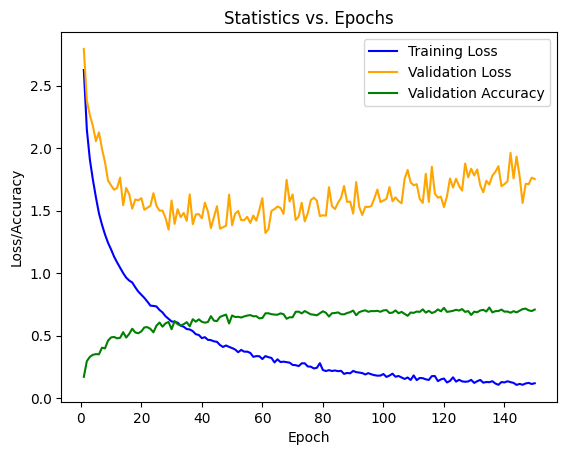

Accuracy: 70.8984%


In [11]:
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 150)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

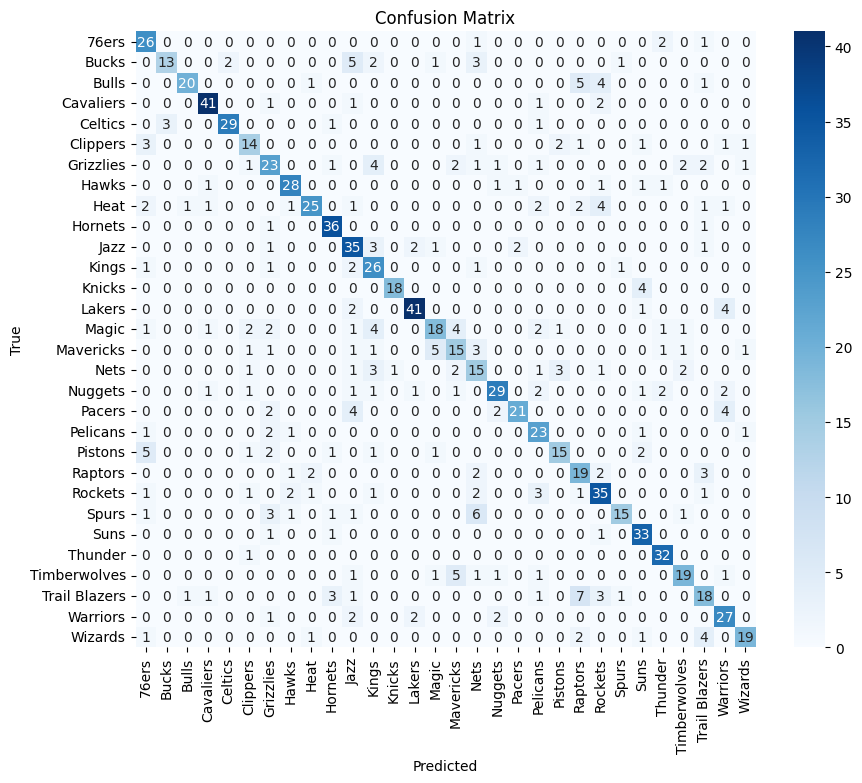

In [24]:
modelPrediction = []
realLabels = []
classNames = trainDataset.classes

with torch.no_grad():
    for inputs, labels in testLoader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        modelPrediction.extend(preds.cpu().numpy())
        realLabels.extend(labels.cpu().numpy())

cm = confusion_matrix(realLabels, modelPrediction)
labels_unique = sorted(set(classNames))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# EvenBetterNet with .2 Dropout

Epoch 1/150, Train Loss: 2.5370, Train Accuracy: 0.2594, Validation Loss: 2.6092, Validation Accuracy: 0.2549
Epoch 2/150, Train Loss: 2.0373, Train Accuracy: 0.3786, Validation Loss: 2.3049, Validation Accuracy: 0.2812
Epoch 3/150, Train Loss: 1.8096, Train Accuracy: 0.4466, Validation Loss: 2.2441, Validation Accuracy: 0.2998
Epoch 4/150, Train Loss: 1.6585, Train Accuracy: 0.4975, Validation Loss: 1.9812, Validation Accuracy: 0.3750
Epoch 5/150, Train Loss: 1.5229, Train Accuracy: 0.5390, Validation Loss: 2.0450, Validation Accuracy: 0.3428
Epoch 6/150, Train Loss: 1.4285, Train Accuracy: 0.5649, Validation Loss: 1.9076, Validation Accuracy: 0.4160
Epoch 7/150, Train Loss: 1.3362, Train Accuracy: 0.5965, Validation Loss: 1.7606, Validation Accuracy: 0.4316
Epoch 8/150, Train Loss: 1.2654, Train Accuracy: 0.6207, Validation Loss: 1.7264, Validation Accuracy: 0.4707
Epoch 9/150, Train Loss: 1.2151, Train Accuracy: 0.6299, Validation Loss: 1.7378, Validation Accuracy: 0.4912
Epoch 10/1

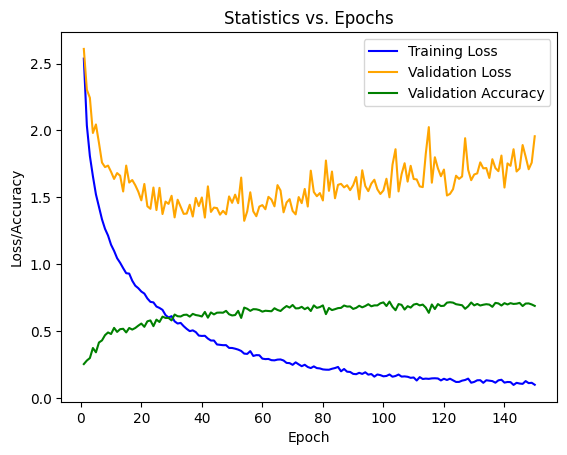

Accuracy: 68.9453%


In [9]:
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 150)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

# EvenBetterNet with .5 dropout selected, added a fourth layer

Epoch 1/75, Train Loss: 2.5971, Train Accuracy: 0.2380, Validation Loss: 2.8499, Validation Accuracy: 0.1825
Epoch 2/75, Train Loss: 2.0830, Train Accuracy: 0.3681, Validation Loss: 2.0797, Validation Accuracy: 0.3353
Epoch 3/75, Train Loss: 1.8313, Train Accuracy: 0.4404, Validation Loss: 1.9422, Validation Accuracy: 0.3689
Epoch 4/75, Train Loss: 1.6672, Train Accuracy: 0.4933, Validation Loss: 1.9440, Validation Accuracy: 0.3622
Epoch 5/75, Train Loss: 1.5426, Train Accuracy: 0.5285, Validation Loss: 1.8394, Validation Accuracy: 0.4159
Epoch 6/75, Train Loss: 1.4255, Train Accuracy: 0.5611, Validation Loss: 1.7971, Validation Accuracy: 0.4256
Epoch 7/75, Train Loss: 1.3308, Train Accuracy: 0.5943, Validation Loss: 1.6216, Validation Accuracy: 0.4832
Epoch 8/75, Train Loss: 1.2794, Train Accuracy: 0.6109, Validation Loss: 1.7538, Validation Accuracy: 0.4448
Epoch 9/75, Train Loss: 1.2056, Train Accuracy: 0.6314, Validation Loss: 1.5706, Validation Accuracy: 0.5187
Epoch 10/75, Train 

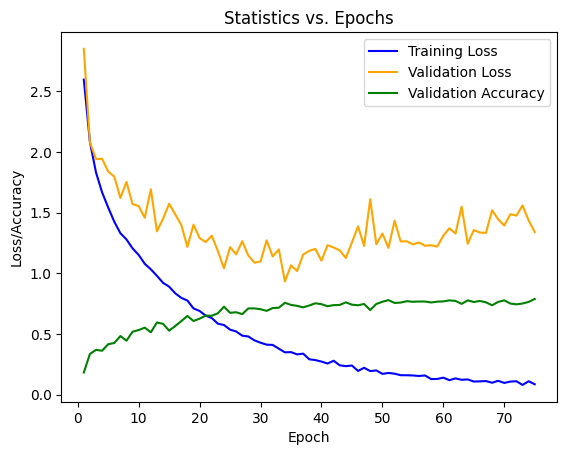

Accuracy: 78.8665%


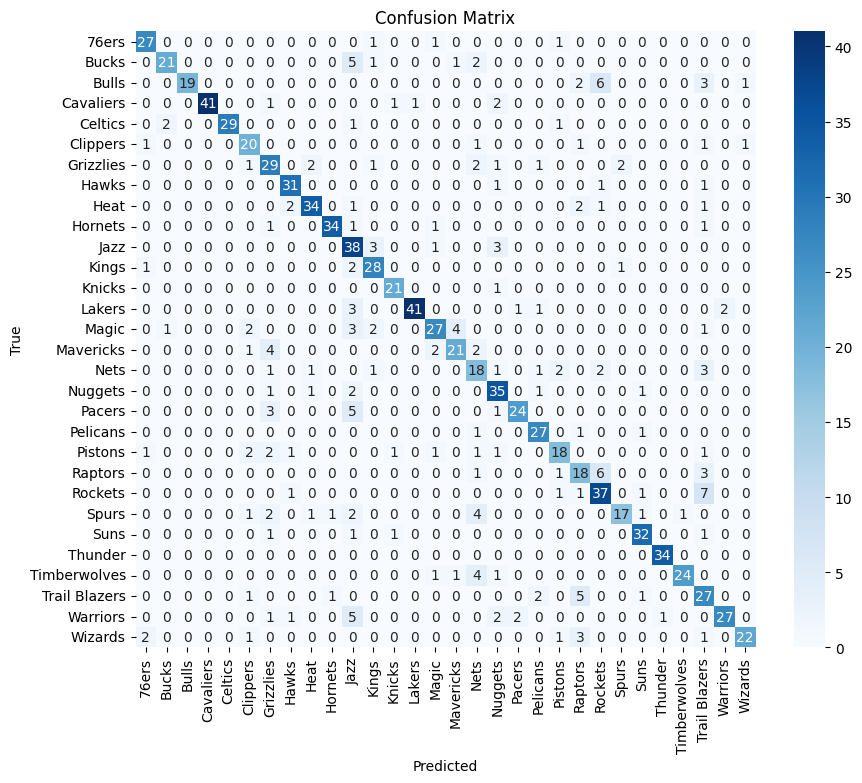

In [7]:
from models.evenbetternet import EvenBetterNet
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

In [36]:
torch.save(model.state_dict(), "EvenBetterNet.pt")

# Trying GELU instead of ReLU

Epoch 1/75, Train Loss: 2.6562, Train Accuracy: 0.2163, Validation Loss: 2.6073, Validation Accuracy: 0.2046
Epoch 2/75, Train Loss: 2.1414, Train Accuracy: 0.3486, Validation Loss: 2.2510, Validation Accuracy: 0.2834
Epoch 3/75, Train Loss: 1.8213, Train Accuracy: 0.4314, Validation Loss: 2.0482, Validation Accuracy: 0.3698
Epoch 4/75, Train Loss: 1.5789, Train Accuracy: 0.5109, Validation Loss: 1.8552, Validation Accuracy: 0.4159
Epoch 5/75, Train Loss: 1.4099, Train Accuracy: 0.5712, Validation Loss: 1.7096, Validation Accuracy: 0.4678
Epoch 6/75, Train Loss: 1.2701, Train Accuracy: 0.6106, Validation Loss: 1.8309, Validation Accuracy: 0.4227
Epoch 7/75, Train Loss: 1.1572, Train Accuracy: 0.6489, Validation Loss: 1.5932, Validation Accuracy: 0.5293
Epoch 8/75, Train Loss: 1.0485, Train Accuracy: 0.6814, Validation Loss: 1.4386, Validation Accuracy: 0.5351
Epoch 9/75, Train Loss: 0.9568, Train Accuracy: 0.7111, Validation Loss: 1.4941, Validation Accuracy: 0.5485
Epoch 10/75, Train 

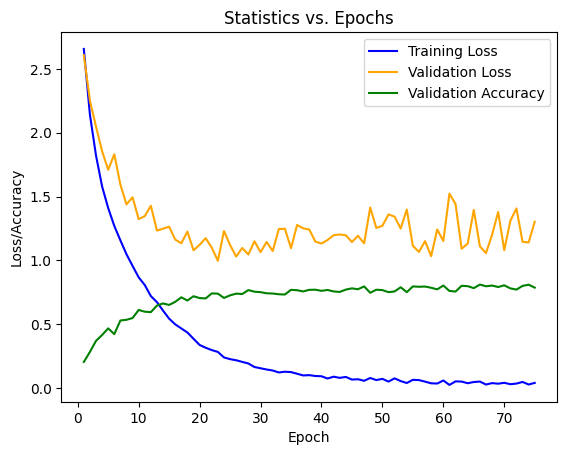

NameError: name 'evaluateModel' is not defined

In [6]:
from models.evenbetternet import EvenBetterNet

model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

# Trying SiLU isntead of GELU

Epoch 1/75, Train Loss: 2.4926, Train Accuracy: 0.2632, Validation Loss: 2.4180, Validation Accuracy: 0.2666
Epoch 2/75, Train Loss: 1.9331, Train Accuracy: 0.4077, Validation Loss: 2.1007, Validation Accuracy: 0.3340
Epoch 3/75, Train Loss: 1.6748, Train Accuracy: 0.4847, Validation Loss: 1.8373, Validation Accuracy: 0.4139
Epoch 4/75, Train Loss: 1.5008, Train Accuracy: 0.5354, Validation Loss: 1.7957, Validation Accuracy: 0.4254
Epoch 5/75, Train Loss: 1.3698, Train Accuracy: 0.5796, Validation Loss: 1.6753, Validation Accuracy: 0.4726
Epoch 6/75, Train Loss: 1.2513, Train Accuracy: 0.6094, Validation Loss: 1.6181, Validation Accuracy: 0.4995
Epoch 7/75, Train Loss: 1.1760, Train Accuracy: 0.6425, Validation Loss: 1.6346, Validation Accuracy: 0.4889
Epoch 8/75, Train Loss: 1.1080, Train Accuracy: 0.6581, Validation Loss: 1.5828, Validation Accuracy: 0.5438
Epoch 9/75, Train Loss: 1.0534, Train Accuracy: 0.6817, Validation Loss: 1.5457, Validation Accuracy: 0.5111
Epoch 10/75, Train 

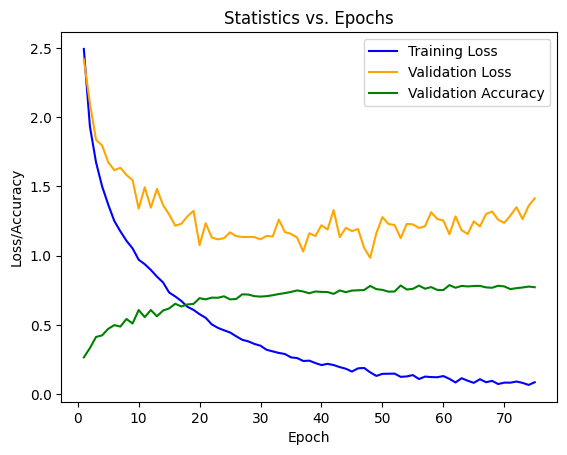

Accuracy: 77.2859%


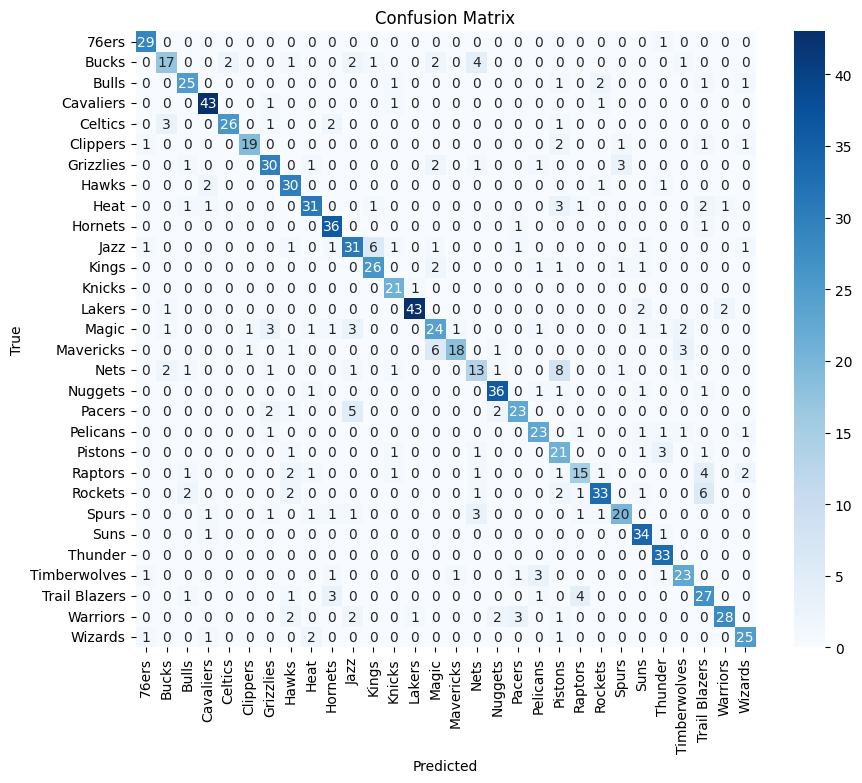

In [7]:
from models.evenbetternet import EvenBetterNet

model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

# 5th layer added using GELU

Epoch 1/75, Train Loss: 2.5793, Train Accuracy: 0.2405, Validation Loss: 2.5648, Validation Accuracy: 0.2358
Model saved!
Epoch 2/75, Train Loss: 1.9681, Train Accuracy: 0.4068, Validation Loss: 2.4345, Validation Accuracy: 0.2608
Model saved!
Epoch 3/75, Train Loss: 1.6869, Train Accuracy: 0.4843, Validation Loss: 1.8782, Validation Accuracy: 0.4013
Model saved!
Epoch 4/75, Train Loss: 1.5089, Train Accuracy: 0.5341, Validation Loss: 1.7897, Validation Accuracy: 0.4167
Model saved!
Epoch 5/75, Train Loss: 1.3581, Train Accuracy: 0.5894, Validation Loss: 1.6466, Validation Accuracy: 0.4928
Model saved!
Epoch 6/75, Train Loss: 1.2344, Train Accuracy: 0.6261, Validation Loss: 1.6039, Validation Accuracy: 0.5005
Model saved!
Epoch 7/75, Train Loss: 1.1305, Train Accuracy: 0.6589, Validation Loss: 1.5345, Validation Accuracy: 0.5361
Model saved!
Epoch 8/75, Train Loss: 1.0315, Train Accuracy: 0.6939, Validation Loss: 1.4841, Validation Accuracy: 0.5659
Model saved!
Epoch 9/75, Train Loss: 

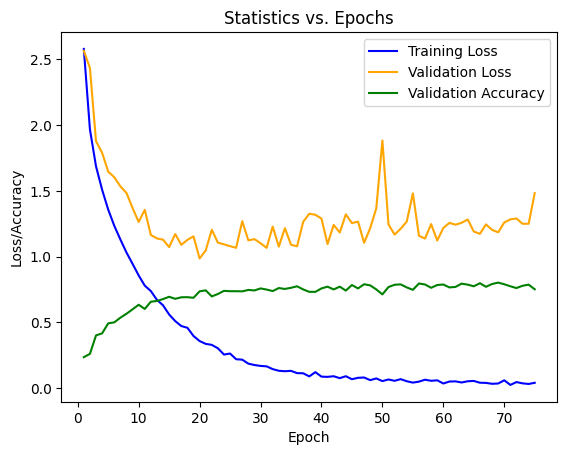

Accuracy: 75.1684%


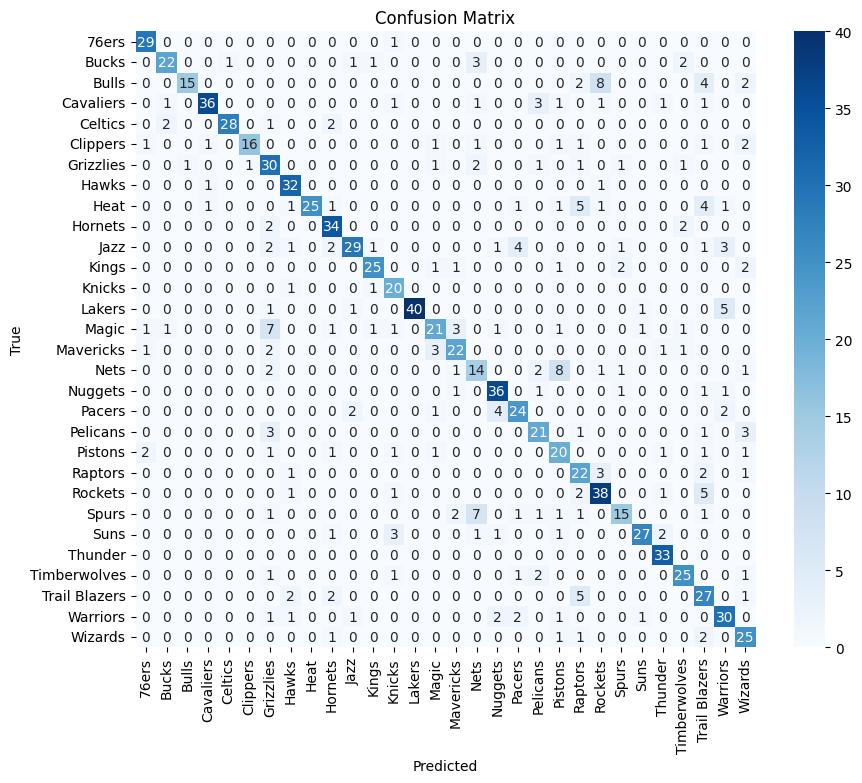

In [7]:
from models.evenbetternet import EvenBetterNet
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

Epoch 1/100, Train Loss: 2.7405, Train Accuracy: 0.2026, Validation Loss: 2.7800, Validation Accuracy: 0.1691
Model saved!
Epoch 2/100, Train Loss: 2.2604, Train Accuracy: 0.3108, Validation Loss: 2.4339, Validation Accuracy: 0.2555
Model saved!
Epoch 3/100, Train Loss: 2.0444, Train Accuracy: 0.3738, Validation Loss: 2.2086, Validation Accuracy: 0.3295
Model saved!
Epoch 4/100, Train Loss: 1.8732, Train Accuracy: 0.4212, Validation Loss: 2.1570, Validation Accuracy: 0.3276
Epoch 5/100, Train Loss: 1.7493, Train Accuracy: 0.4618, Validation Loss: 2.0721, Validation Accuracy: 0.3718
Model saved!
Epoch 6/100, Train Loss: 1.6404, Train Accuracy: 0.4958, Validation Loss: 2.0393, Validation Accuracy: 0.3573
Epoch 7/100, Train Loss: 1.5712, Train Accuracy: 0.5172, Validation Loss: 1.7223, Validation Accuracy: 0.4390
Model saved!
Epoch 8/100, Train Loss: 1.4576, Train Accuracy: 0.5554, Validation Loss: 1.7572, Validation Accuracy: 0.4361
Epoch 9/100, Train Loss: 1.4030, Train Accuracy: 0.5688

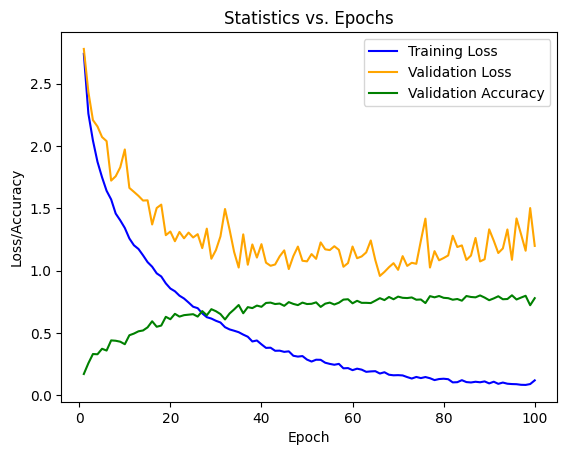

Accuracy: 77.8098%


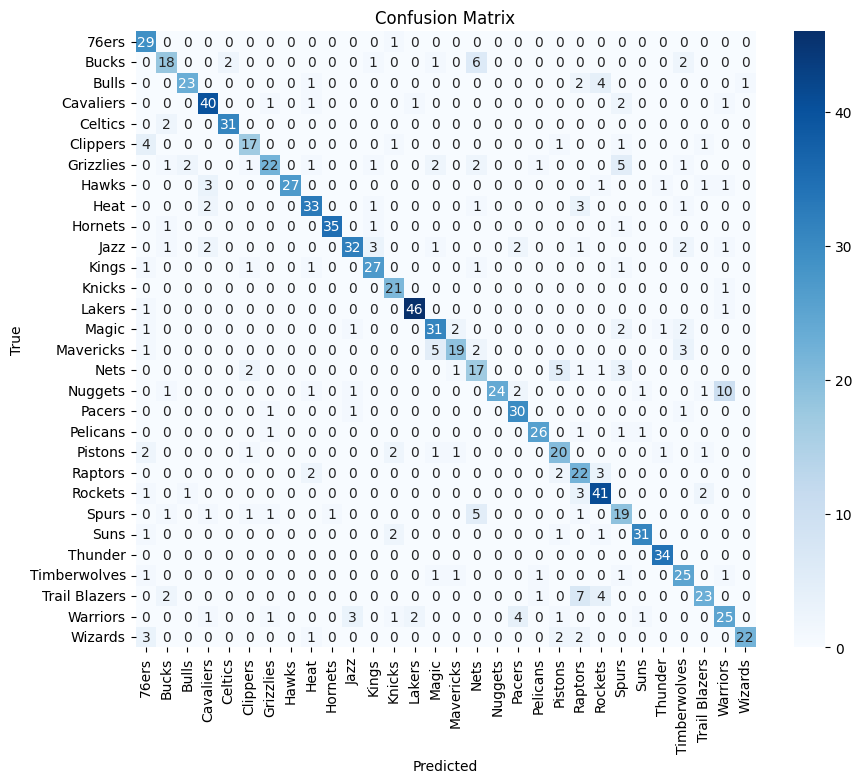

In [7]:
from models.evenbetternet import EvenBetterNet
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 100)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

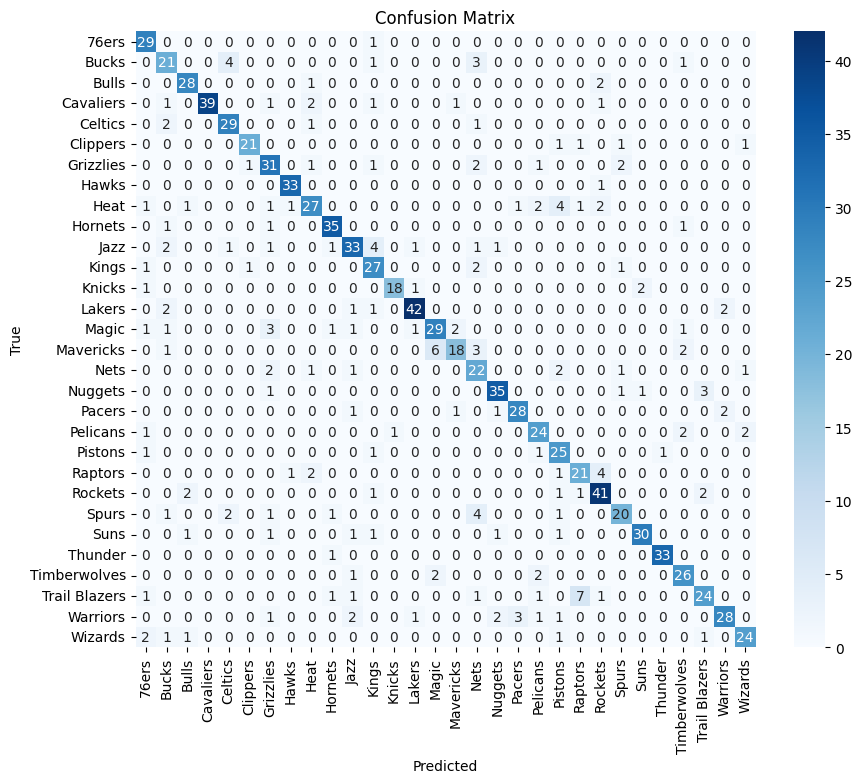

In [18]:
# Load the best_modelReLU.pt and plot the confusion matrix
model = EvenBetterNet().to(device)
model.load_state_dict(torch.load("best_modelReLU.pt", map_location=device))
model.eval()
plotConfusionMatrix(model, testLoader)

In [19]:
# print the accuracy of every class using the loaded model
model = EvenBetterNet().to(device)
model.load_state_dict(torch.load("best_modelReLU.pt", map_location=device))
model.eval()
correct = 0
total = 0
classAccuracies = [0] * len(trainDataset.classes)
classCounts = [0] * len(trainDataset.classes)
# Team Names
teams = ["76ers", "Bucks", "Bulls", "Cavaliers", "Celtics", "Clippers", "Grizzlies", "Hawks", "Heat", "Hornets", "Jazz", "Kings", "Knicks", "Lakers", "Magic", "Mavericks", "Nets", "Nuggets", "Pacers", "Pelicans", "Pistons", "Raptors", "Rockets", "Spurs", "Suns", "Thunder", "Timberwolves", "Trail Blazers", "Warriors", "Wizards"]
with torch.no_grad():
    for images, labels in testLoader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for i in range(len(labels)):
            classCounts[labels[i]] += 1
            if predicted[i] == labels[i]:
                classAccuracies[labels[i]] += 1

# Calculate the accuracy for each class
for i in range(len(classAccuracies)):
    if classCounts[i] > 0:
        classAccuracies[i] = classAccuracies[i] / classCounts[i]
    else:
        classAccuracies[i] = 0

# Print the accuracy for each class
for i in range(len(classAccuracies)):
    print(f"Class {teams[i]} Accuracy: {classAccuracies[i]:.4f}")

# Print average class accuracy
avgClassAccuracy = sum(classAccuracies) / len(classAccuracies)
print(f"Average Class Accuracy: {avgClassAccuracy:.4f}")

Class 76ers Accuracy: 0.9667
Class Bucks Accuracy: 0.7000
Class Bulls Accuracy: 0.9032
Class Cavaliers Accuracy: 0.8478
Class Celtics Accuracy: 0.8788
Class Clippers Accuracy: 0.8400
Class Grizzlies Accuracy: 0.7949
Class Hawks Accuracy: 0.9706
Class Heat Accuracy: 0.6585
Class Hornets Accuracy: 0.9211
Class Jazz Accuracy: 0.7333
Class Kings Accuracy: 0.8438
Class Knicks Accuracy: 0.8182
Class Lakers Accuracy: 0.8750
Class Magic Accuracy: 0.7250
Class Mavericks Accuracy: 0.6000
Class Nets Accuracy: 0.7333
Class Nuggets Accuracy: 0.8537
Class Pacers Accuracy: 0.8485
Class Pelicans Accuracy: 0.8000
Class Pistons Accuracy: 0.8621
Class Raptors Accuracy: 0.7241
Class Rockets Accuracy: 0.8542
Class Spurs Accuracy: 0.6667
Class Suns Accuracy: 0.8333
Class Thunder Accuracy: 0.9706
Class Timberwolves Accuracy: 0.8387
Class Trail Blazers Accuracy: 0.6486
Class Warriors Accuracy: 0.7179
Class Wizards Accuracy: 0.8000
Average Class Accuracy: 0.8076


Epoch 1/5, Train Loss: 2.3573, Train Accuracy: 0.3348, Validation Loss: 3.0091, Validation Accuracy: 0.1710
Epoch 2/5, Train Loss: 0.6926, Train Accuracy: 0.8083, Validation Loss: 4.0136, Validation Accuracy: 0.1892
Epoch 3/5, Train Loss: 0.0906, Train Accuracy: 0.9763, Validation Loss: 5.5137, Validation Accuracy: 0.1710
Epoch 4/5, Train Loss: 0.0571, Train Accuracy: 0.9853, Validation Loss: 5.8121, Validation Accuracy: 0.1671
Epoch 5/5, Train Loss: 0.0800, Train Accuracy: 0.9787, Validation Loss: 6.8474, Validation Accuracy: 0.1864


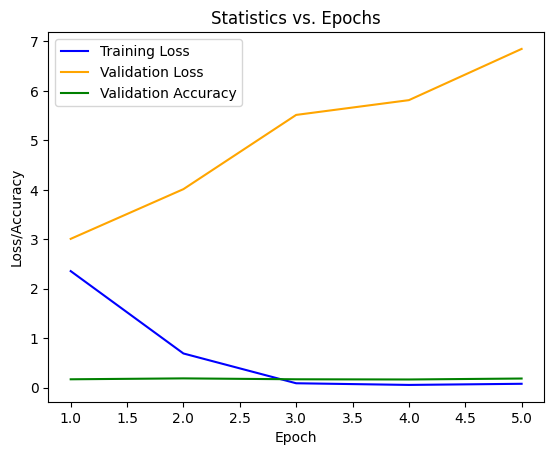

Accuracy: 18.6359%


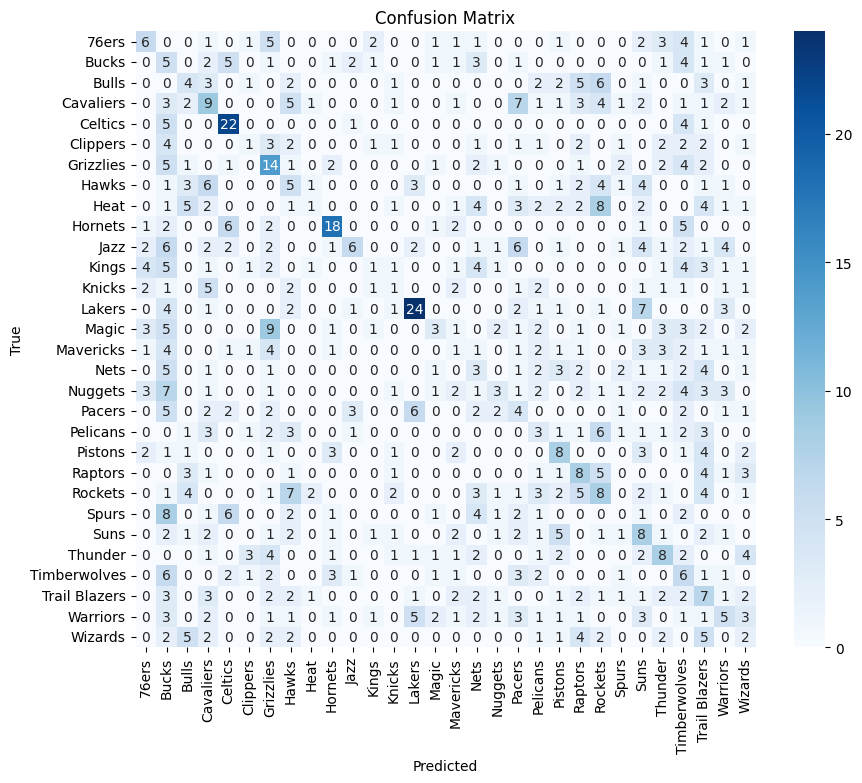

In [8]:
from models.net import Net
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 5)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

In [9]:
# print the accuracy of every class using the loaded model
model.eval()
correct = 0
total = 0
classAccuracies = [0] * len(trainDataset.classes)
classCounts = [0] * len(trainDataset.classes)
# Team Names
teams = ["76ers", "Bucks", "Bulls", "Cavaliers", "Celtics", "Clippers", "Grizzlies", "Hawks", "Heat", "Hornets", "Jazz", "Kings", "Knicks", "Lakers", "Magic", "Mavericks", "Nets", "Nuggets", "Pacers", "Pelicans", "Pistons", "Raptors", "Rockets", "Spurs", "Suns", "Thunder", "Timberwolves", "Trail Blazers", "Warriors", "Wizards"]
with torch.no_grad():
    for images, labels in testLoader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for i in range(len(labels)):
            classCounts[labels[i]] += 1
            if predicted[i] == labels[i]:
                classAccuracies[labels[i]] += 1

# Calculate the accuracy for each class
for i in range(len(classAccuracies)):
    if classCounts[i] > 0:
        classAccuracies[i] = classAccuracies[i] / classCounts[i]
    else:
        classAccuracies[i] = 0

# Print the accuracy for each class
for i in range(len(classAccuracies)):
    print(f"Class {teams[i]} Accuracy: {classAccuracies[i]:.4f}")

# Print average class accuracy
avgClassAccuracy = sum(classAccuracies) / len(classAccuracies)
print(f"Average Class Accuracy: {avgClassAccuracy:.4f}")

Class 76ers Accuracy: 0.2000
Class Bucks Accuracy: 0.1667
Class Bulls Accuracy: 0.1290
Class Cavaliers Accuracy: 0.1957
Class Celtics Accuracy: 0.6667
Class Clippers Accuracy: 0.0400
Class Grizzlies Accuracy: 0.3590
Class Hawks Accuracy: 0.1471
Class Heat Accuracy: 0.0244
Class Hornets Accuracy: 0.4737
Class Jazz Accuracy: 0.1333
Class Kings Accuracy: 0.0312
Class Knicks Accuracy: 0.0455
Class Lakers Accuracy: 0.5000
Class Magic Accuracy: 0.0750
Class Mavericks Accuracy: 0.0333
Class Nets Accuracy: 0.1000
Class Nuggets Accuracy: 0.0732
Class Pacers Accuracy: 0.1212
Class Pelicans Accuracy: 0.1000
Class Pistons Accuracy: 0.2759
Class Raptors Accuracy: 0.2759
Class Rockets Accuracy: 0.1667
Class Spurs Accuracy: 0.0000
Class Suns Accuracy: 0.2222
Class Thunder Accuracy: 0.2353
Class Timberwolves Accuracy: 0.1935
Class Trail Blazers Accuracy: 0.1892
Class Warriors Accuracy: 0.1282
Class Wizards Accuracy: 0.0667
Average Class Accuracy: 0.1789


# Trying 6th layer


Epoch 1/75, Train Loss: 2.8429, Train Accuracy: 0.1750, Validation Loss: 2.7892, Validation Accuracy: 0.1748
Epoch 2/75, Train Loss: 2.4046, Train Accuracy: 0.2707, Validation Loss: 2.4176, Validation Accuracy: 0.2402
Epoch 3/75, Train Loss: 2.1615, Train Accuracy: 0.3303, Validation Loss: 2.2909, Validation Accuracy: 0.2622
Epoch 4/75, Train Loss: 2.0158, Train Accuracy: 0.3772, Validation Loss: 2.2436, Validation Accuracy: 0.2968
Epoch 5/75, Train Loss: 1.9037, Train Accuracy: 0.4025, Validation Loss: 2.0955, Validation Accuracy: 0.3256
Epoch 6/75, Train Loss: 1.7934, Train Accuracy: 0.4380, Validation Loss: 2.0082, Validation Accuracy: 0.3525
Epoch 7/75, Train Loss: 1.7057, Train Accuracy: 0.4671, Validation Loss: 1.9055, Validation Accuracy: 0.3679
Epoch 8/75, Train Loss: 1.6079, Train Accuracy: 0.4991, Validation Loss: 1.8547, Validation Accuracy: 0.4140
Epoch 9/75, Train Loss: 1.5209, Train Accuracy: 0.5276, Validation Loss: 1.8761, Validation Accuracy: 0.4304
Epoch 10/75, Train 

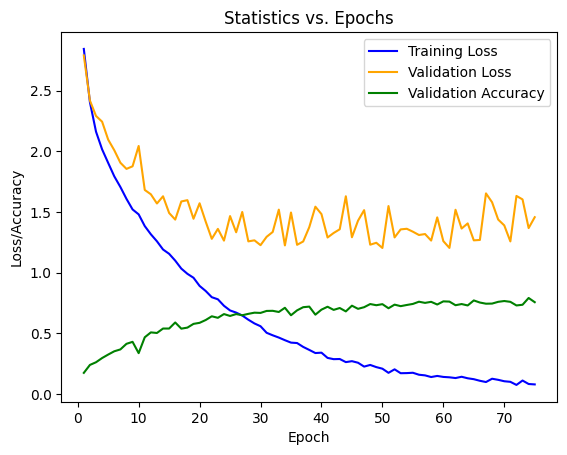

Accuracy: 75.6964%


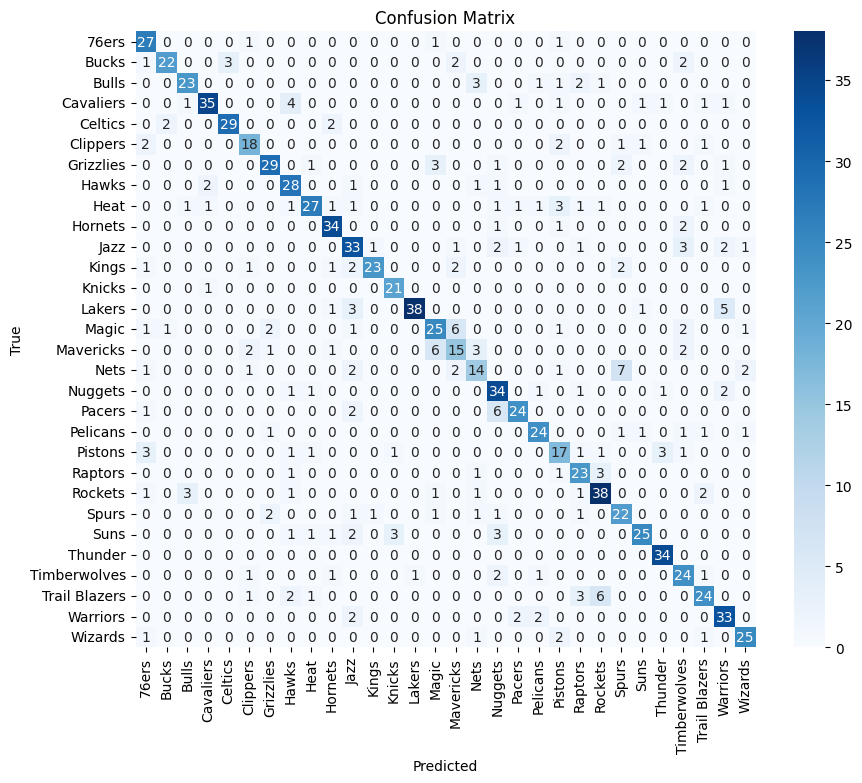

In [7]:
from models.evenbetternet import EvenBetterNet
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

# 5 Layers but one is 128x128

Epoch 1/75, Train Loss: 2.7382, Train Accuracy: 0.1995, Validation Loss: 2.9201, Validation Accuracy: 0.2027
Epoch 2/75, Train Loss: 2.2770, Train Accuracy: 0.3064, Validation Loss: 2.4721, Validation Accuracy: 0.2498
Epoch 3/75, Train Loss: 2.0005, Train Accuracy: 0.3831, Validation Loss: 2.0464, Validation Accuracy: 0.3622
Epoch 4/75, Train Loss: 1.8149, Train Accuracy: 0.4415, Validation Loss: 2.0886, Validation Accuracy: 0.3554
Epoch 5/75, Train Loss: 1.6752, Train Accuracy: 0.4844, Validation Loss: 1.8877, Validation Accuracy: 0.3794
Epoch 6/75, Train Loss: 1.5748, Train Accuracy: 0.5098, Validation Loss: 2.0333, Validation Accuracy: 0.3573
Epoch 7/75, Train Loss: 1.4971, Train Accuracy: 0.5418, Validation Loss: 1.8329, Validation Accuracy: 0.4265
Epoch 8/75, Train Loss: 1.4084, Train Accuracy: 0.5632, Validation Loss: 1.8295, Validation Accuracy: 0.4111
Epoch 9/75, Train Loss: 1.3096, Train Accuracy: 0.5935, Validation Loss: 1.6300, Validation Accuracy: 0.4890
Epoch 10/75, Train 

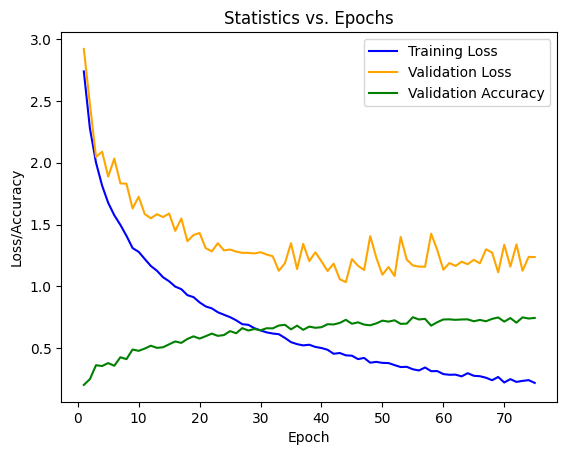

Accuracy: 74.4476%


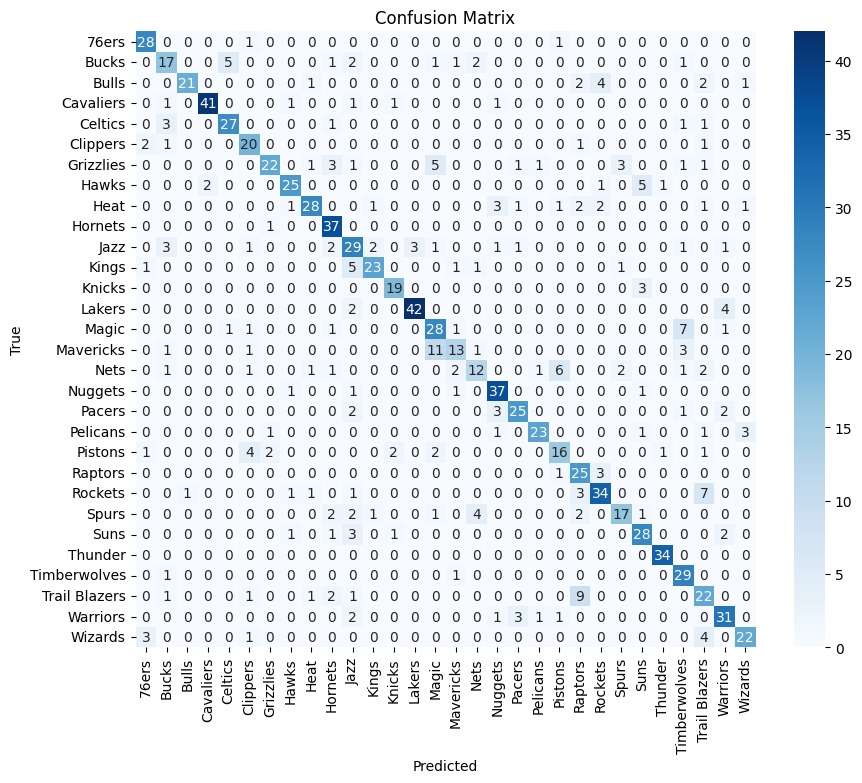

In [7]:
from models.evenbetternet import EvenBetterNet
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

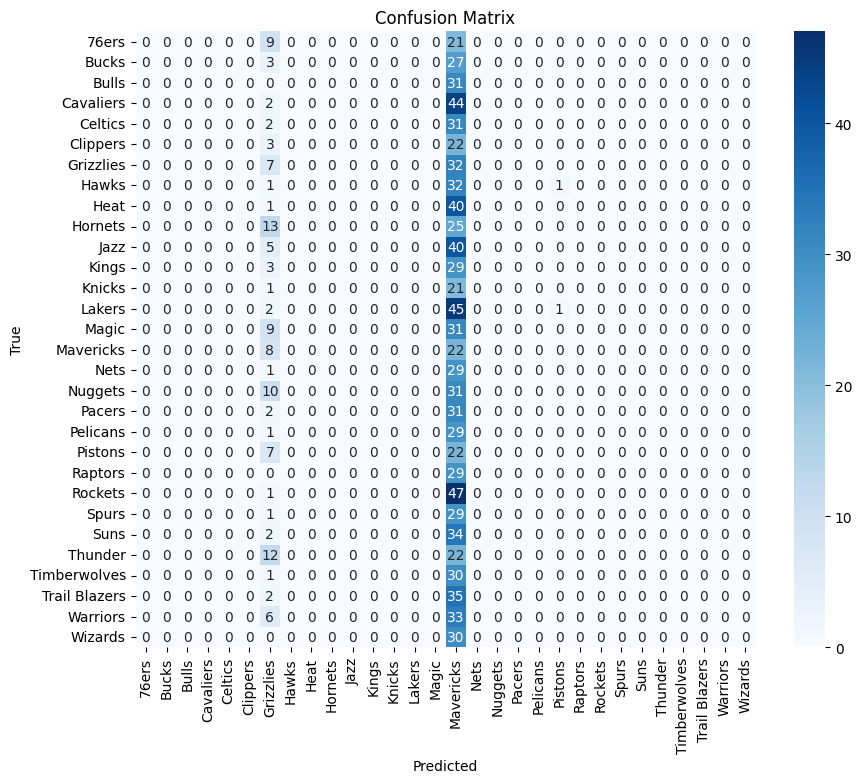

In [6]:
from models.evenbetternet import EvenBetterNet
model = EvenBetterNet().to(device)
#Load the best model params
model.load_state_dict(torch.load("best_modelReLU.pt"))
model.eval()
plotConfusionMatrix(model, testLoader)
